# Density Based Clustering

## Why Do We Need New Methods?
Last week, we introduced the concept of K-Means as our fundamental clustering algorithm. It was made up of 2 key pieces:
1. Assign groups randomly, and
2. Modify your groups until you have minimized their within-group variation.

This is a powerful method, but has its faults. You likely found some of these yourself, but a few key items are:
- K-Means assumes clusters are spherical (or can be represented as a distance from a central point). This means it cannot represent non-circular data.
- K-Means, like many other methods, is very sensitive to noise. A single point that is far away from the others would be defined as its own group, rather than meaningfully filtered out.
- You need to pick the number of groups, K, rather than finding an optimal one.

You might be wondering "but... when does real data have these flaws?"

Of course, outliers are a problem in any dataset where you collected data from some real life experiment. Medical data is full of these, as "if the human brain was simple enough that we could understand it, we would be simple enough that we couldn't." But other data exists, for example:
- Spatial data showing city densities is often not spherical. For example, most coastal cities hug the coast very closely, and otherwise cities follow rivers, mountains, and roads.
- Image processing is another great example. Not every picture is made up of clear spheres.

Thus, in seeking to address these issues, we will need to develop a new method. In this section, we will introduce DBSCAN, a "density-based spatial clustering of applications with noise" method.

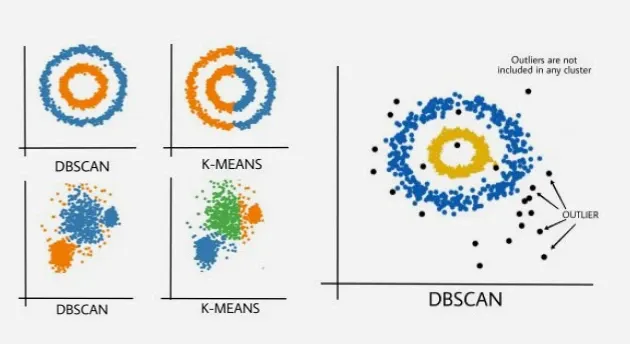

Figure 2.1. An example of DBSCAN vs K-Means. Taken from GeeksForGeeks.

Source: https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/


## What is DBSCAN?
Unlike K-Means, which seeks to cluster based on nearest mean, DBSCAN splits your dataset into 3 categories:
1. A series of "core points" which have a large number of neighbours,
2. Border points which are near a core but don't have enough neighbours to themselves be a core, and
3. Noise points which aren't a core nor near a core.

This requires us to identify two variables of interest:
1. $\epsilon$ - The distance from the point that is counted as "close", and
2. MinPts - The minumum number of points that we count as a "large number" of neighbours.

So, the algorithm effectively goes to each point and asks "hey, do you have at least MinPts neighbours within a range of $\epsilon$?" If yes, then that's a core point. Once this is done, it only **then** goes to each point that isn't a core and asks "hey, are you within a distance of $\epsilon$ from a core?" If yes, then that point is in the same cluster as that core.

The next natural question, then, is "what happens when you have a chain of connected cores? Is that a bunch of different clusters?" This is the beauty of DBSCAN - If multiple cores are near each other, forming a chain, they form **only one cluster**, this is clearly seen in Figure 2.1.

Let's now do this a bit more mathematically. Consider each point in our dataset $D = \{x_1, x_2, \dots, x_m\}$, where each $x$ may be multidimensional. Then, we hgave the following:
- An **$\epsilon$-neighbourhood** is all samples in D which have a distance to $x_j$ no larger than $\epsilon$. That is, $N_\epsilon(x_j) = \{ x_i \in D | d(x_i, x_j) \leq \epsilon\}$
- A **core** is any $x_j$ such that $N_\epsilon(x_j) > \text{MinPts}$.
- $x_j$ is said to be **directly density-reachable** by $x_i$ if $x_i$ is a core object and $x_j$ is in the $\epsilon$-neighbour of $x_i$. $x_j$ is density-reachable if there is a sequence of directly density-reachable points between $x_j$ and $x_i$ that connect to both $x_j$ and $x_i$.
- $x_j$ is said to be **density-connected** to $x_i$ if there exists an $x_k$ such that each is density-reachable from each other $x_k$, but $x_k$ is not necessarily a core point.

Let us give an image from "Machine Learning" by Zhi-Hua Zhou. Here, you can see that $x_1$ is a core, $x_2$ is directly density-reachable by $x_1$, $x_3$ is density reachable, and $x_4$ is density-connected to $x_3$.

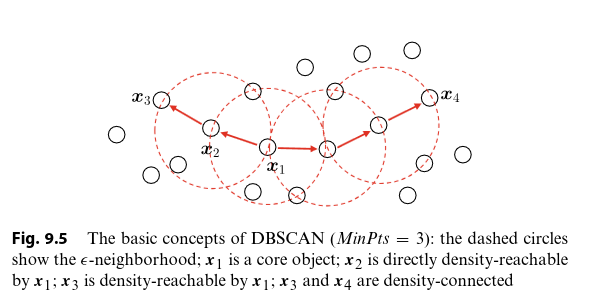

## Building a DBSCAN Algorithm
While this concept is quite simple, making an algorithm for it can be... harder. Mostly due to this question of "which points are within $\epsilon$ of each other point?" Thankfully, K-Means has equipped us very well for this! This question of finding all points within a distance of $\epsilon$ will be called a Range Query, just to split the code up. The algorithm is as follows:

```Python
DBSCAN(Data, epsilon, MinPts):
  ClusterNumber = 0

  for each point in Data:

    if point has already been visited, skip to next point

    otherwise, mark point as visited and keep going

    Neighbours = RangeQuery(Data, point, epsilon)

    if number of neighbours < minPts:
      label point as "noise"

    else:
      ClusterNumber = ClusterNumber + 1
      
      create a new cluster with this number
      mark x as belonging to ClusterNumber

      # Now we will expand the cluster as much as we can
      for each newpoint in neighbours:
        if newpoint has already been visited and is not noise, skip it

        mark the newpoint as belonging to ClusterNumber

        PNeighbours = RangeQuery(Data, newpoint, eps)

        add all of PNeighbours to the end of Neighbours list
        #Note that this loop will then also do ALL OF THIS WORK on those newly added points!
```

This seems complicated, but in practice its literally just:
1. Check if a point can make a cluster
2. If so, check all of its neighbours, and see if they form a core
3. Then check all of THEIR neighbours to see if they have cores,
4. Then check all of THEIR neighbours...
5. ...
6. Finish


Finally, let us write our exactly how RangeQuery works:
```Python
RangeQuery(Data, point, epsilon):
  neighbours = (empty list)

  for each D in data:
    if distance(point, D) <= epsilon:
      add D to neighbours

  return neighbours
```

The same textbook we cited above has a good image showcasing this process!

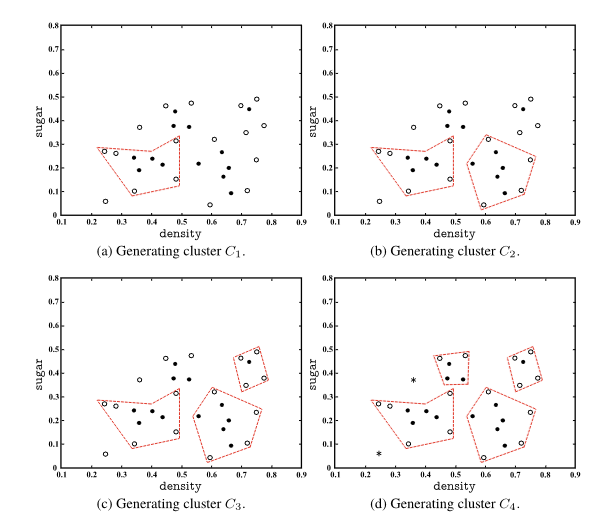

Figure 2.1. Building clusters using DBSCAN. Taken from Machine Learning [2], chapter 9.5.

## Let's Talk About This Algorithm
This algorithm is **incredibly powerful** for clustering. It meets all of our requirements above:
- It forms its own number of clusters naturally from the shape of the data,
- It is able to capture weird shapes of clusters, as long as the points are close enough for that shape to be well defined, and
- It is functionally immune to noise, just deleting noise points that otherwise don't fit into clusters.

This gives us some very clear use cases!
1. Fraud Detection - If you can define people's behaviour, especially financial behaviour, and apply clustering to it, you can very clearly find patterns of actions that are "abnormal" and worth investigating.
2. Tumor Detection - Given MRI or other medical scans, you can find regions of uniquely different density or behaviour. These regions in the body, when compared to surrounding muscle, bone, and other standard functions, could be tumors.
3. Computer Vision - Grouping nearby pixels into definitive shapes, which can then be fed into a learning algorithm, such as a neural net.

So, what are the drawbacks? Why isn't this the **only** clustering method when its so powerful, and even uses the same distance metric as K-Means?
1. Runtime - Let's put it this way: Checking the distance between every single point is slow. This was true for K-Means as well. When you have $n$ points and need to compare every single one, the total number of comparisons is $n^2$, giving us a runtime of $\mathcal{O}(n^2)$ (if you are unfamiliar with the big O, it just means that as you increase the size of $n$ towards some large number, the number of steps the algorithm must take increases in this way compared to $n$). Other methods, like BIRCH, are able to do much better.
2. Sensitivity - DBSCAN is very sensitive to your choice of $\epsilon$ and MinPts. If you have data with some large, sparse groups, and some highly close-together groups, that could render DBSCAN unusable. In other words, **one density value must work for the whole dataset**.
3. Probability - Like K-Means, DBSCAN is deterministic, it doesn't give probability of belonging to cluster A or B, even when some border points could reasonably be in both without forming a clear density-connection.

So, let's ask a question: When should I use K-Means, and when should I use DBSCAN?
- Use K-Means when the data naturally looks like it forms "blobs around centres".
- Use DBSCAN when the data looks dense with weird shapes.

Though, we now have one more interesting question: How do you even know if the method you used is "good" or "bad"?

# "Good" vs "Bad" Clustering

This topic is a bit more difficult than just defining a method. Now that we have established 2 perfectly usable methods for clustering, our question thus becomes "how do we know if one is 'better' than the other?"

The short answer is: **you don't**. This is a stats problem in general. If you have data that looks normally distributed, and even lines up perfectly with the normal distribution, that **doesn't** mean that the problem you're studying is fundamentally normally distributed, and no test can tell you that. Similarly, there is no test that can tell you if your clusters are good or bad.

So, i we can't simply say "this cluster is good" or "this cluster is bad" with a test... what do we do?

The simplest answer is checking your data. Here are some good questions to ask!

## Do The Clusters Make Visual Sense?

If you plot your data with the clusters shown clearly, you can ask if the clusters line up with the clusters you can visually see.

Think back to figure 2.1: K-Means split a circle in half to form its clusters. Very clearly, there are at least 2 points in that image that are nearly touching, and yet they are in different clusters! Is that reasonable? Does that make sense? Maybe, but you need to ask this to yourself based on your data.

## Do The Clusters Match The Method Assumptions?
K-Means works with circles around a central point. DBSCAN works with dense connected reasons. So, you should then ask "does my data or the clusters I just got from a test match up with these assumptions?" If no, its time to change methods.

## Are The Clusters Interpretable?
Your data isn't just random numbers, and you as a person are not an unsupervised learning algorithm. You have context, so ask yourself "do these clusters match categories I would expect from the data?"

For example, if your data is based on purchases, do the clusters line up with frequent small purchases, a few large purchases, and seasonal customers? Or maybe poorer vs richer customers? Is there some way to easily explain each customer?

Or, from Téa's research: Do the clusters line up with dynamical ocean regions? In this case, the correct answer could actually be "no, you cannot cluster these regions", but if one method doesn't work, its best to check more!

If your clusters don't have explainable patterns, that is a hint that something **might** have went wrong.

## Are The Clusters *Useful*?
This is more a group of questions, based on the above point. But its very fair to ask:
1. Do these clusters help us understand the data?
2. Do these clusters help us make decisions?
3. Do these clusters reveal patterns?

For example, tumor detection above was one exact use case. A decision could be "should we do an invasive test here to check?" If the clustering doesn't help answer this, maybe the method or clustering as a whole isn't appropriate.

If clustering doesn't help you answer a question, it usn't useful.

## Are The Clusters Stable?
This one is very simple: If rerunning the method changes the clusters, there could be a problem. If changing one parameter very slightly, like $\epsilon$ in DBSCAN completely changes the data, there could be a problem. Maybe your clusters then aren't physical or "real" to the data, but simply numerical.

# Tasks
For this question list, we have 2 tasks for you:
1. Program DBSCAN and use it to cluster some data and look for outliers
2. On an image, use both DBSCAN and K-Means to see which can handle clustering an image better!

## Task 1 - Find The Imposter
In this task, it will be your goal to **program your own version of DBSCAN using the steps above**. You will use it on some data we provide! Your mission, should you choose to accept it, is as follows:


> A group of spacepeople, on their ship from a far away planet in a year in which faster-than-light space travel exists, have recently happened upon the dead body of one of their crewmates. They are certain that at least one person in the crew did it, and it is your job to figure out who did it.

Each spaceman is named by the color of their badge, so you have "RED", "GREEN", "BLUE", "PINK", "CYAN", "YELLOW", "PURPLE", "ORANGE", and "GREY". The one they found was "WHITE".

**NOTE:** Because clustering algorithms see a big number as "different" or "bad", we have flipped the measure of "distance to body" so that "the closer they are, the bigger the number".

Below is a list of 5 details you have on each of the 9 remaining crewmates:
1. Inverse distance to the body at time of discovery.
2. Number of contradictions you found in their story when interviewed.
3. Number of minutes they were away from the main group or their station.
4. Number of malfunctions that occured at their station today.
5. Number of other crewmates who are suspicious of them.

Your goal is to use **your knowledge of clustering** to figure out who did it. Please cluster them as "INNOCENT" and "GUILTY" (clusters 1 and 2). There are two schools of thought:
1. Define a pattern of similar behaviour and see who is the "furthest" away from the average crewmate, or
2. Define a "group" of similar behaviour and see who doesn't belong to this group.

These correspond to K-Means and DBSCAN. Below, you will **implement DBSCAN** and use K-Means from last week to figure out who is most likely to be guilty.

One last thing: DBSCAN can be a bit finicky. You might not get a good answer with any choice of epsilon. Play around with it, you'll know you got it when only one value is returned! For this question, we don't expect you to implement an epsilon checking method, but if you want to, here is a link:
https://blog.dailydoseofds.com/p/how-to-find-optimal-epsilon-value

**NOTE**: If your K-Means didn't work last week, here is the code for SciKit Learn:
```Python
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2,n_init=20)

kmeans_labels = kmeans.fit_predict(X)
```

In [35]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# =========================
# CREWMATE DATA
# =========================
crewmates = np.array([
    "RED",
    "GREEN",
    "BLUE",
    "PINK",
    "CYAN",
    "YELLOW",
    "PURPLE",
    "ORANGE",
    "GREY"
])

# Columns:
#0. Inverse distance to the body at time of discovery.
#1. Number of contradictions you found in their story when interviewed.
#2. Number of minutes they were away from the main group or their station.
#3. Number of malfunctions that occured at their station today.
#4. Number of other crewmates who are suspicious of them.

mystery_data = np.array([
    [80, 0, 0, 0, 0],   # RED
    [74, 1, 1, 1, 1],   # GREEN
    [68, 2, 2, 2, 2],   # BLUE
    [49, 6, 2, 5, 2],   # PINK
    [56, 4, 4, 4, 4],   # CYAN
    [50, 5, 5, 5, 5],   # YELLOW
    [44, 6, 6, 6, 6],   # PURPLE
    [38, 7, 7, 7, 7],   # ORANGE
    [62, 3, 3, 3, 3],   # GREY
], dtype=float)


# =========================
# SCALE DATA
# =========================

scaler = MinMaxScaler()
X = scaler.fit_transform(mystery_data)

# =========================
# DISTANCE FUNCTION
# =========================

def distance(x,y):
  # For each piece of x and y:
  # 1. Subtract the pieces
  # 2. Then square each value
  # 3. Then take the sum
  # 4. Get the final distance by square rooting it
  distance = np.sqrt(np.sum((x-y)**2))
  return distance

# =========================
# DBSCAN
# =========================

def range_query(X, point_index, epsilon):
    """
    Find all neighbours of point_index.

    A neighbour is any point whose distance from point_index
    is less than or equal to epsilon.

    Return a list of indices, not a list of points.
    """

    neighbors = []

    # --------------------------------
    # Step 1: Loop through every point
    # --------------------------------

    for j in range(X.shape[0]):

      # --------------------------------
      # Step 2: Measure the distance
      # --------------------------------
      # Compare X[point_index] and X[j].

      dist = np.sqrt(np.sum((X[point_index] - X[j])**2))

      # --------------------------------
      # Step 3: Check if it is close enough
      # --------------------------------
      # If dist <= epsilon, then j is a neighbour.
      if dist <= epsilon:
            neighbors.append(j)

      pass

    return neighbors

def dbscan(X, eps, minPts):
    """
    Perform DBSCAN clustering here!

    Output:
        labels, an array of shape (n_points,)

    Suggested label convention:
        0 means unassigned
       -1 means noise
        1 means cluster 1
        2 means cluster 2
        and so on
    """

    # Get the total number of points
    n_points = X.shape[0]

    # --------------------------------
    # Step 1: Set up bookkeeping
    # --------------------------------
    # visited[i] should tell us whether point i has been checked.
    # labels[i] should tell us which cluster point i belongs to.

    visited = np.full(n_points, False)
    labels = np.full(n_points, 0)

    cluster_number = 0

    for i in range(n_points):

        # --------------------------------
        # Step 2a: Skip visited points
        # --------------------------------
        # If point i has already been visited, skip it.

        if visited[i]:
            continue

        # --------------------------------
        # Step 2b: Mark point as visited
        # --------------------------------

        visited[i] = True

        # --------------------------------
        # Step 2c: Find neighbours
        # --------------------------------

        neighbours = range_query(X, i, eps)

        # --------------------------------
        # Step 2d: Check if point is noise
        # --------------------------------
        # If point i does not have enough neighbours,
        # label it as noise.

        if len(neighbours) < minPts:
            labels[i] = -1

        # Else: Make a cluster
        else:
            # --------------------------------
            # Step 2e: Start a new cluster
            # --------------------------------

            cluster_number += 1
            labels[i] = cluster_number

            # --------------------------------
            # Step 2f: Expand the cluster
            # --------------------------------
            # This is the main DBSCAN step.
            # You may want to use a while loop here.

            for j in neighbours:
                if visited[j]:
                    continue

                visited[j] = True

                labels[j] = cluster_number

                pneighbours = range_query(X, j, eps)

                neighbours.extend(pneighbours)
            pass

    return labels

# CALL YOUR DBSCAN CODE HERE AND PRINT THE LABELS
# In this setup:
# DBSCAN label 0 should be the innocent cluster.
# DBSCAN label -1 should be the isolated guilty person.

dbscan_labels = dbscan(X, eps=0.5, minPts=2)
print(dbscan_labels)

imposter = crewmates[dbscan_labels == -1]
print("The imposter is " + imposter)

# eps = 0.5, minPts = 2 --> PINK
# eps = 0.6, minPts = 3 --> RED

# =========================
# K-MEANS
# =========================

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2,n_init=20)

kmeans_labels = kmeans.fit_predict(X)
print(kmeans_labels)

[ 1  1  1 -1  1  1  1  1  1]
['The imposter is PINK']
[1 1 1 0 0 0 0 0 1]


## Task 2 - Image Processing
Now that you've got an idea of how to implement DBSCAN, let's explore another use case for implementing it: IMAGE PROCESSING!

Your next mission, should you choose to accept it, is as follows:

> *So you have helped the space people determine the prime **sus****pect of their crewmate's murder. The group has decided on throwing the suspect out of the ship's airlock into the vast unknown of space, as punishment for their crimes...*

>*Since this is a harsh action, you want make to make sure that the suspect you chose really is guilty. Luckily the ship is equipped with a state of the art Image Mapping for Point-based Outlier Segmentation and Target Evidence Recognition Scanner, also known as the **IMPOSTOR Scanner***

>*Unfortunately, some of the software for this scanner seems to have been broken in one of the many **sus****picious system failures that have occurred today. Now the system can only implement k-means clustering. Let's help fix the system by implementing some DBSCAN image checking functionality*

The **sus**pect data structure is a 2D array of size 6526 x 5, it has 6526 pixel points, each with 5 pieces of information: X coordinate, Y cooredinate, Red, Green, and Blue values.

Your task is to run it through clustering with each of K-Means and DBSCAN (the one you created above), compare the results, and see if you can find anything suspicious!

Don't forget some of the differences between K-Means & DBSCAN:

    K-Means algorithms cluster all the instances in the datasets whereas DBSCAN doesn’t assign noise points (outliers) to a valid cluster
    K-Means has difficulty with non-global clusters (ohno but we're in space) whereas DBSCAN can handle that smoothly


**NOTE**: If your K-Means didn't work last week, here is the code for SciKit Learn:
```python
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2,n_init=20)

kmeans_labels = kmeans.fit_predict(sus_data)
```


In [36]:
###############################################################################
#This code generates the data to be clustered
#You DO NOT need to edit this
#Ignore this entire code block
#Your code block is below this one!
###############################################################################

import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap

#CONSTANTS
np.random.seed(42)
fx, fy = 0.85, 3.0
fa, fb = 0.9, 0.45

BODY_CY = 2.35
BODY_A = 1.4
BODY_B = 2.3
BODY_OUTLINE_CLIP = 0.025
OUTLINE_SPACING = 0.008

RED = np.array([255, 0, 0])
CYAN = np.array([0, 255, 255])
BLUE = np.array([0, 0, 255])
BLACK = np.array([0, 0, 0])
GREEN  = np.array([  0, 180,   0])
YELLOW = np.array([255, 255,   0])
PURPLE = np.array([153,   0, 204])
ORANGE = np.array([255, 128,   0])
PINK   = np.array([255, 102, 179])
GRAY   = np.array([128, 128, 128])
PLOT_COLORS = np.array([PINK, CYAN, YELLOW, BLACK, PURPLE, GREEN, ORANGE, PINK, GRAY, BLUE, RED])/255
COLOR_CMAP = ListedColormap(PLOT_COLORS)

#HELPER FUNCTIONS

def ellipse_points(cx, cy, a, b, n):
    """Create an Ellipse out of points."""
    theta = np.random.uniform(0, 2*np.pi, n)
    r = np.sqrt(np.random.uniform(0, 1, n))
    x = cx + a * r * np.cos(theta)
    y = cy + b * r * np.sin(theta)
    return x, y

def rectangle_points(cx, cy, w, h, n):
    """Create a Rectangle out of points."""
    x = np.random.uniform(cx - w/2, cx + w/2, n)
    y = np.random.uniform(cy - h/2, cy + h/2, n)
    return x, y

def point_to_segment_distance(px, py, x1, y1, x2, y2):
    """
    Distance from points (px, py) to the line segment from (x1, y1) to (x2, y2).
    px and py can be numpy arrays.
    """
    vx = x2 - x1
    vy = y2 - y1

    wx = px - x1
    wy = py - y1

    seg_len_sq = vx * vx + vy * vy

    # Projection parameter t onto the segment
    t = (wx * vx + wy * vy) / seg_len_sq
    t = np.clip(t, 0.0, 1.0)

    proj_x = x1 + t * vx
    proj_y = y1 + t * vy

    dx = px - proj_x
    dy = py - proj_y

    return np.sqrt(dx * dx + dy * dy)

def body_level(x, y):
    """Define where body is"""
    return (x / BODY_A)**2 + ((y - BODY_CY) / BODY_B)**2

def in_body(x, y):
    """Check if point is in body"""
    return body_level(x, y) <= 1

def in_body_or_outline_band(x, y):
    """Check if point is in body or outline band"""
    return body_level(x, y) <= 1 + BODY_OUTLINE_CLIP

def body_lower_y(x):
    """Adjust body to meet leg outline"""
    val = 1 - (x / BODY_A)**2
    val = np.maximum(val, 0)
    return BODY_CY - BODY_B * np.sqrt(val)

def in_visor(x, y):
    """Check if point is in visor"""
    return ((x - fx) / fa)**2 + ((y - fy) / fb)**2 <= 1

def in_leg(x, y):
    """Check if point is in leg"""
    left_leg = (x > -0.9) & (x < -0.15) & (y > -0.3) & (y < 1.0)
    right_leg = (x > 0.15) & (x < 0.9) & (y > -0.3) & (y < 1.0)
    return left_leg | right_leg

def in_backpack(x, y):
    """Check if point is in backpack"""
    return (x > -1.9) & (x < -1.3) & (y > 1.3) & (y < 3.2)

def ellipse_outline(cx, cy, a, b, n):
    """Add outline to body"""
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    theta += np.random.normal(0, 0.01, n)
    return cx + a*np.cos(theta), cy + b*np.sin(theta)

def line_points(x1, y1, x2, y2, spacing=OUTLINE_SPACING):
    """Add outline points"""
    length = np.hypot(x2 - x1, y2 - y1)
    n = max(2, int(np.ceil(length / spacing)))
    x = np.linspace(x1, x2, n)
    y = np.linspace(y1, y2, n)
    return x, y

def rectangle_outline(cx, cy, w, h, spacing=OUTLINE_SPACING):
    """Add leg and backpack outline points, deal with density spacing"""
    x_min, x_max = cx - w/2, cx + w/2
    y_min, y_max = cy - h/2, cy + h/2

    x_top, y_top = line_points(x_min, y_max, x_max, y_max, spacing)
    x_right, y_right = line_points(x_max, y_max, x_max, y_min, spacing)
    x_bot, y_bot = line_points(x_max, y_min, x_min, y_min, spacing)
    x_left, y_left = line_points(x_min, y_min, x_min, y_max, spacing)

    return (
        np.concatenate([x_top, x_right, x_bot, x_left]),
        np.concatenate([y_top, y_right, y_bot, y_left])
    )

def leg_outline(cx, cy, w, h, spacing=OUTLINE_SPACING):
    """Draw only the visible leg outline"""
    x_min, x_max = cx - w/2, cx + w/2
    y_min, y_max = cy - h/2, cy + h/2

    # Where each vertical side enters the body ellipse.
    y_left_join = body_lower_y(x_min)
    y_right_join = body_lower_y(x_max)

    # Clamp to the actual leg rectangle.
    y_left_join = np.clip(y_left_join, y_min, y_max)
    y_right_join = np.clip(y_right_join, y_min, y_max)

    # Bottom edge.
    x_bot, y_bot = line_points(x_min, y_min, x_max, y_min, spacing)

    # Visible side edges, ending exactly at body outline.
    x_left, y_left = line_points(x_min, y_min, x_min, y_left_join, spacing)
    x_right, y_right = line_points(x_max, y_min, x_max, y_right_join, spacing)

    return (
        np.concatenate([x_bot, x_left, x_right]),
        np.concatenate([y_bot, y_left, y_right])
    )

def leg_hole_fix(px, py, thickness=0.08):
    """
    Select existing body points that belong to hole in the legs from numpy.
    """

    curve = np.array([
        [0.20, 2.45],
        [0.42, 2.25],
        [0.68, 2.10],
        [0.95, 2.05],
        [1.18, 2.14],
        [1.30, 2.32],
    ])

    interior = [
        ((0.48, 2.22), (0.42, 1.92)),
        ((0.72, 2.10), (0.68, 1.82)),
        ((0.95, 2.07), (0.98, 1.80)),
        ((1.15, 2.18), (1.24, 1.95)),
    ]

    min_dist = np.full(px.shape, np.inf)

    for start, end in zip(curve[:-1], curve[1:]):
        d = point_to_segment_distance(
            px, py,
            start[0], start[1],
            end[0], end[1]
        )
        min_dist = np.minimum(min_dist, d)

    for (x1, y1), (x2, y2) in interior:
        d = point_to_segment_distance(px, py, x1, y1, x2, y2)
        min_dist = np.minimum(min_dist, d)

    mask = min_dist <= thickness
    mask = mask & in_body(px, py) & (~in_visor(px, py))

    return mask

def apply_mask(x, y, mask_fn):
    """Masking cutout function"""
    m = mask_fn(x, y)
    return x[m], y[m]

def mask_body_outline(x, y):
    """Remove body outline with legs and face overlap"""
    leg_mask = in_leg(x, y)
    visor_mask = in_visor(x, y)
    return ~(visor_mask | (leg_mask & (y > 0.0)))

def mask_backpack(x, y):
    """Backpack mask"""
    return ~(in_body_or_outline_band(x, y) | in_visor(x, y) | in_leg(x, y))

def make_component_array(x, y, rgb):
    """Create array
       Rows: [X, Y, R, G, B]
    """
    n = len(x)
    r = np.full(n, rgb[0])
    g = np.full(n, rgb[1])
    b = np.full(n, rgb[2])

    return np.column_stack([x, y, r, g, b])

def make_labels(name, n):
    """Optional labels for checking clustering quality"""
    return np.full(n, name, dtype=object)

def make_cluster_features(data_5d, rgb_weight=0.18):
    """
    Convert raw [X, Y, R, G, B] data into clustering features

    X/Y are scaled to [0, 1]
    RGB is scaled to [0, rgb_weight]

    This prevents RGB values like 255 from dominating the geometry
    """
    xy = MinMaxScaler().fit_transform(data_5d[:, 0:2])

    rgb = data_5d[:, 2:5] / 255.0
    rgb = rgb * rgb_weight

    return np.column_stack([xy, rgb])

#CREATE SHAPES

body_x, body_y = ellipse_points(0, BODY_CY, BODY_A, BODY_B, 5000)
leg1_x, leg1_y = rectangle_points(-0.525, 0.12, 0.85, 1.50, 500)
leg2_x, leg2_y = rectangle_points(0.525, 0.12, 0.85, 1.50, 500)
back_x, back_y = rectangle_points(-1.6, 2.2, 0.6, 1.9, 900)
face_x, face_y = ellipse_points(fx, fy, fa, fb, 700)

#Create character that combines body and legs, remove overlap with face
character_x = np.concatenate([body_x, leg1_x, leg2_x])
character_y = np.concatenate([body_y, leg1_y, leg2_y])
visor_mask = ~in_visor(character_x, character_y)
character_x, character_y = character_x[visor_mask], character_y[visor_mask]
leg_fix_mask = leg_hole_fix(character_x, character_y)

leg_fix_x = character_x[leg_fix_mask]
leg_fix_y = character_y[leg_fix_mask]

# Remove those points from the normal red body
character_x = character_x[~leg_fix_mask]
character_y = character_y[~leg_fix_mask]
B1ACK = np.array([255, 25, 25])

#CREATE OUTLINES

body_outline_x, body_outline_y = ellipse_outline(0, BODY_CY, BODY_A, BODY_B, 800)
leg1_outline_x, leg1_outline_y = leg_outline(-0.525, 0.12, 0.85, 1.50)
leg2_outline_x, leg2_outline_y = leg_outline(0.525, 0.12, 0.85, 1.50)
back_outline_x, back_outline_y = rectangle_outline(-1.6, 2.2, 0.6, 1.9)
face_outline_x, face_outline_y = ellipse_outline(fx, fy, fa, fb, 600)

#APPLY MASKS

body_outline_x, body_outline_y = apply_mask(body_outline_x, body_outline_y, mask_body_outline)
back_outline_x, back_outline_y = apply_mask(back_outline_x, back_outline_y, mask_backpack)
back_x, back_y = apply_mask(back_x, back_y, mask_backpack)

#BUILD ARRAYS

character_arr = make_component_array(character_x, character_y, RED)
face_arr = make_component_array(face_x, face_y, CYAN)
backpack_arr = make_component_array(back_x, back_y, BLUE)

body_outline_arr = make_component_array(body_outline_x, body_outline_y, BLACK)
face_outline_arr = make_component_array(face_outline_x, face_outline_y, BLACK)
backpack_outline_arr = make_component_array(back_outline_x, back_outline_y, BLACK)
left_leg_outline_arr = make_component_array(leg1_outline_x, leg1_outline_y, BLACK)
right_leg_outline_arr = make_component_array(leg2_outline_x, leg2_outline_y, BLACK)
leg_fix_arr = make_component_array(leg_fix_x, leg_fix_y, B1ACK)

#STACK DATA

data_5d = np.vstack([
    character_arr,
    face_arr,
    backpack_arr,
    body_outline_arr,
    face_outline_arr,
    backpack_outline_arr,
    left_leg_outline_arr,
    right_leg_outline_arr,
    leg_fix_arr
])

# Optional ground-truth labels for testing clustering
# These are NOT included in data_5d
true_labels_text = np.concatenate([
    make_labels("red_body_and_legs", len(character_arr)),
    make_labels("visor_fill", len(face_arr)),
    make_labels("backpack_fill", len(backpack_arr)),
    make_labels("body_outline", len(body_outline_arr)),
    make_labels("visor_outline", len(face_outline_arr)),
    make_labels("backpack_outline", len(backpack_outline_arr)),
    make_labels("left_leg_outline", len(left_leg_outline_arr)),
    make_labels("right_leg_outline", len(right_leg_outline_arr)),
])

_, true_labels = np.unique(true_labels_text, return_inverse=True)

#Perform standard scaling, accounting for weights of RGB
sus_data = make_cluster_features(data_5d, rgb_weight=0.33)

#Print the shape of the data to be clustered
print(f"Data shape: {sus_data.shape}\n")
#Print the first 5 examples of data
print(f"First 5 Values [X, Y, R, G, B]: \n{sus_data[:5]}")

Data shape: (9271, 5)

First 5 Values [X, Y, R, G, B]: 
[[0.35088048 0.75822705 0.33       0.         0.        ]
 [0.48052439 0.16429138 0.33       0.         0.        ]
 [0.33850995 0.41684543 0.33       0.         0.        ]
 [0.71971041 0.90185568 0.33       0.         0.        ]
 [0.75602727 0.26555347 0.33       0.         0.        ]]


### Write your code here!

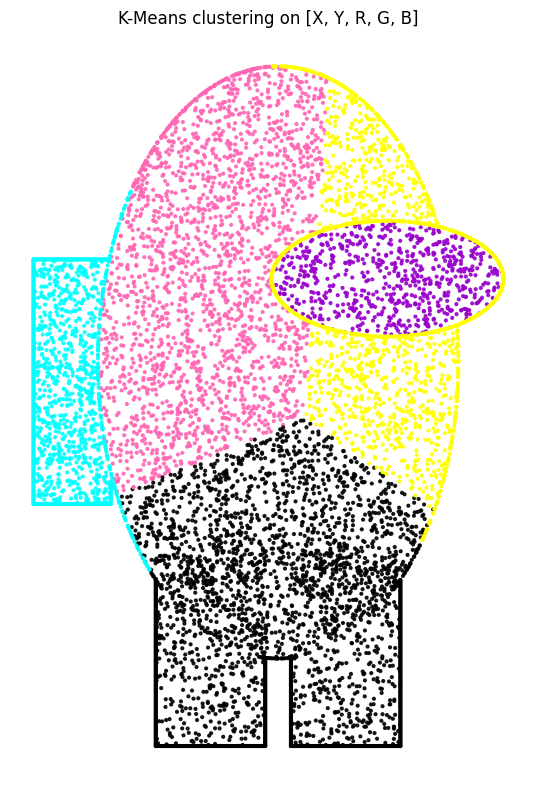

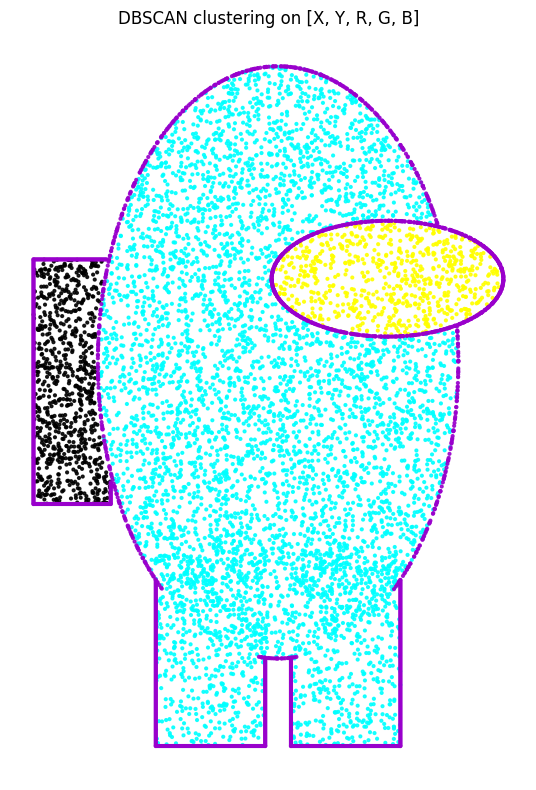

In [37]:
#Try K-Means
#Suggested K = 5

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,n_init=20)

kmeans_labels = kmeans.fit_predict(sus_data)

#Try DBSCAN
#You will need to try different variables
#Suggested eps between 0 and 0.1
#Suggested min_samples between 1 and 30

dbscan_labels = dbscan(sus_data, eps=0.05, minPts=15)

# =========================
# PLOTS
# =========================
def plot_cluster_result(data_5d, labels, title="DBSCAN vs K-Means"):
    xy = data_5d[:, 0:2]

    color_indices = labels.copy()

    color_indices[color_indices == -1] = 3

    color_indices = color_indices % len(PLOT_COLORS)

    point_colors = PLOT_COLORS[color_indices]

    plt.figure(figsize=(8, 8))
    plt.scatter(
        xy[:, 0],
        xy[:, 1],
        s=4,
        c=point_colors,
        alpha=0.85
    )
    plt.gca().set_aspect("equal")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cluster_result(data_5d, kmeans_labels, title="K-Means clustering on [X, Y, R, G, B]")
plot_cluster_result(data_5d, dbscan_labels, title="DBSCAN clustering on [X, Y, R, G, B]")

# TA-DA! You saved the crewmates! :D

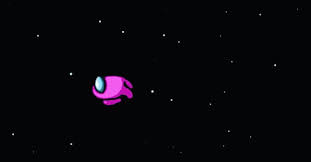

## Bonus Question
Try clustering that image above! Here is the code to load it, and this should work with your own.

**Make sure to read the comments below about loading images!**

image_data_5d shape: (50382, 5)
First 5 rows:
[[0.         0.         0.00522876 0.00653595 0.00915033]
 [0.00322581 0.         0.00522876 0.00653595 0.00915033]
 [0.00645161 0.         0.00522876 0.00653595 0.00915033]
 [0.00967742 0.         0.00522876 0.00653595 0.00915033]
 [0.01290323 0.         0.00522876 0.00653595 0.00915033]]


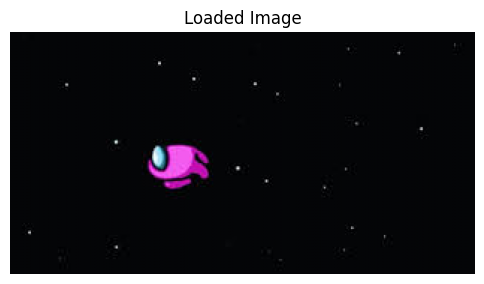

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

# =========================
# LOCAL IMAGE TO 5D ARRAY
# =========================

def image_file_to_5d_array(filename, rgb_weight=1/3, remove_background=False, background_threshold=0.03):
    """
    Convert a local image file into a NumPy array with rows:

        [x, y, R, G, B]

    where:
        x, y are scaled to [0, 1]
        R, G, B are scaled to [0, rgb_weight]

    Parameters
    ----------
    filename : str
        Path to the local image file.

    rgb_weight : float
        RGB scaling factor. Use 1/3 so RGB values lie in [0, 1/3].

    remove_background : bool
        If True, removes very dark background pixels.

    background_threshold : float
        Pixels with average RGB below this value are removed when
        remove_background=True.

    Returns
    -------
    data_5d : np.ndarray
        Array of shape (n_pixels, 5).

    image_array : np.ndarray
        Original RGB image scaled to [0, 1].
    """

    # Read image
    image_array = imread(filename)

    # If image has alpha channel, remove it
    if image_array.ndim == 3 and image_array.shape[2] == 4:
        image_array = image_array[:, :, :3]

    # If grayscale, convert to RGB
    if image_array.ndim == 2:
        image_array = np.stack([image_array, image_array, image_array], axis=-1)

    # Make sure RGB is in [0, 1]
    if image_array.max() > 1:
        image_array = image_array / 255.0

    height, width, _ = image_array.shape

    # ------------------------------
    # Build x/y coordinates
    # ------------------------------

    y_coords, x_coords = np.meshgrid(
        np.arange(height),
        np.arange(width),
        indexing="ij"
    )

    x_scaled = x_coords.flatten() / (width - 1)
    y_scaled = y_coords.flatten() / (height - 1)

    # ------------------------------
    # Build RGB values
    # ------------------------------

    rgb_scaled = image_array.reshape(-1, 3) * rgb_weight

    # ------------------------------
    # Final 5D array
    # ------------------------------

    data_5d = np.column_stack([
        x_scaled,
        y_scaled,
        rgb_scaled
    ])

    # ------------------------------
    # Optional: remove black background
    # ------------------------------

    if remove_background:
        brightness = rgb_scaled.mean(axis=1)
        keep_mask = brightness > background_threshold
        data_5d = data_5d[keep_mask]

    return data_5d, image_array

# ------------------------------
# NOTE: THIS DOES NOT WORK ON COLAB UNLESS YOU GET THE PATH RIGHT
# YOU MUST GIVE THE PATH TO THIS IMAGE LOCALLY ON YOUR COMPUTER
# OR WHERE IT IS IN GOOGLE COLAB
# ------------------------------
PATH_TO_THE_IMAGE = "./sus.jpeg"
image_data_5d, image_array = image_file_to_5d_array(
    PATH_TO_THE_IMAGE,
    rgb_weight=1/3,
    remove_background=False
)

print("image_data_5d shape:", image_data_5d.shape)
print("First 5 rows:")
print(image_data_5d[:5])

plt.figure(figsize=(6, 6))
plt.imshow(image_array)
plt.axis("off")
plt.title("Loaded Image")
plt.show()

In [58]:
# CLUSTER IT HERE! GOOD LUCK! :D

data_5d, image_array = image_file_to_5d_array("susjpeg.jpeg", rgb_weight=1/3, remove_background=False, background_threshold=0.03)
dbscan_labels = dbscan(data_5d, eps=0.2, minPts=10)

# --------------------
# PLOTTING
# --------------------

def plot_image_clusters(image_array, labels, title):
    height, width, _ = image_array.shape

    label_image = labels.reshape(height, width)

    plt.figure(figsize=(6, 6))
    plt.imshow(label_image, cmap="tab20")
    plt.axis("off")
    plt.title(title)
    plt.show()

print(data_5d)
plot_image_clusters(image_array, dbscan_labels, "DBSCAN Image Clustering")
plot_image_clusters(image_array, kmeans_labels, "K-Means Image Clustering")

KeyboardInterrupt: 

## References
1. https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/
2. Zhou, Zhi-Hua. "Machine Learning." Chapter 9.5 - Density Clustering. Springer Singapore. 978-981-15-1967-3 Published: 20 August 2021.